In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

In [2]:
data = pd.read_csv(r"diabetes.csv")
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [4]:
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
corr = data.corr()
top_features = corr["Outcome"].abs().sort_values(ascending=False)[1:6]
selected_features = top_features.index.tolist()

print("top 5", selected_features)

top 5 ['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction']


In [8]:
X = data[selected_features]
y = data["Outcome"]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=selected_features)
print(X.head())

    Glucose       BMI       Age  Pregnancies  DiabetesPedigreeFunction
0  0.743719  0.500745  0.483333     0.352941                  0.234415
1  0.427136  0.396423  0.166667     0.058824                  0.116567
2  0.919598  0.347243  0.183333     0.470588                  0.253629
3  0.447236  0.418778  0.000000     0.058824                  0.038002
4  0.688442  0.642325  0.200000     0.000000                  0.943638


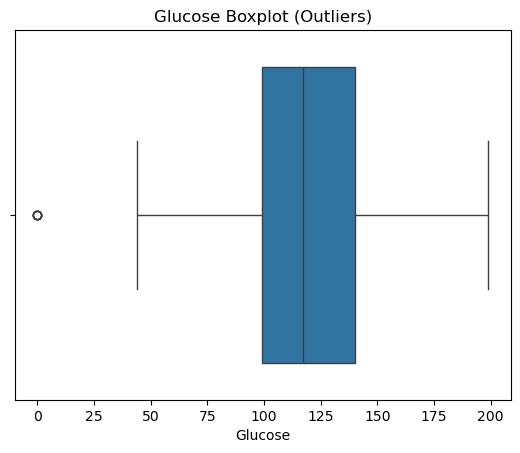

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
feature = "Glucose"
sns.boxplot(x=data[feature])
plt.title(f"{feature} Boxplot (Outliers)")
plt.show()

In [10]:
Q1 = data[feature].quantile(0.25)
Q3 = data[feature].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data_clean = data[(data[feature] >= lower) & (data[feature] <= upper)]

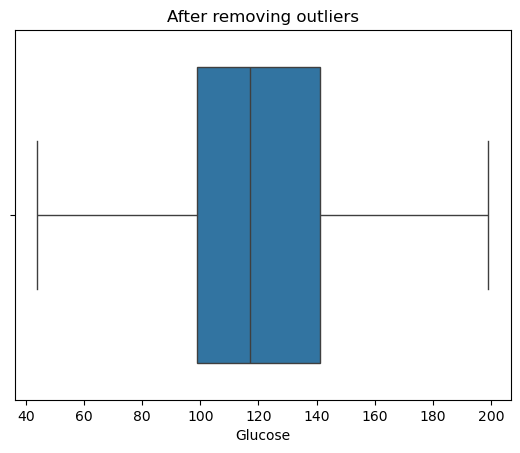

In [11]:
sns.boxplot(x=data_clean[feature])
plt.title("After removing outliers")
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

In [22]:
C_values = [50, 10, 1.0, 0.1, 0.01]

best_acc = 0
best_C = None
best_cm = None

for C in C_values:
    svm = SVC(C=C, kernel='rbf', gamma='auto')
    svm.fit(X_train, y_train)
    
    y_pred = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"C={C}, Accuracy={acc}")
                                                                                    
    if acc > best_acc:
        best_acc = acc
        best_C = C
        best_cm = confusion_matrix(y_test, y_pred)

print("\nBest C:", best_C)
print("Confusion Matrix:\n", best_cm)

C=50, Accuracy=0.7559055118110236
C=10, Accuracy=0.7559055118110236
C=1.0, Accuracy=0.7637795275590551
C=0.1, Accuracy=0.6614173228346457
C=0.01, Accuracy=0.6614173228346457

Best C: 1.0
Confusion Matrix:
 [[148  20]
 [ 40  46]]


In [14]:
best_k = 0
best_acc_knn = 0

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"k={k}, Accuracy={acc}")
    
    if acc > best_acc_knn:
        best_acc_knn = acc
        best_k = k

print("\nBest k:", best_k)

k=1, Accuracy=0.7012987012987013
k=2, Accuracy=0.6796536796536796
k=3, Accuracy=0.7142857142857143
k=4, Accuracy=0.696969696969697
k=5, Accuracy=0.7142857142857143
k=6, Accuracy=0.7142857142857143
k=7, Accuracy=0.7316017316017316
k=8, Accuracy=0.7316017316017316
k=9, Accuracy=0.7316017316017316
k=10, Accuracy=0.7619047619047619
k=11, Accuracy=0.7489177489177489
k=12, Accuracy=0.7532467532467533
k=13, Accuracy=0.7272727272727273
k=14, Accuracy=0.7445887445887446
k=15, Accuracy=0.7402597402597403
k=16, Accuracy=0.7445887445887446
k=17, Accuracy=0.7489177489177489
k=18, Accuracy=0.7575757575757576
k=19, Accuracy=0.7445887445887446
k=20, Accuracy=0.7532467532467533

Best k: 10


In [23]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7401574803149606


In [24]:
bag = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=best_k),
    n_estimators=10,
    random_state=42
)

bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, bag_pred))

Bagging Accuracy: 0.7401574803149606


In [25]:
svm = SVC(kernel='rbf', gamma='auto', probability=True)

boost = AdaBoostClassifier(estimator=svm, n_estimators=10)
boost.fit(X_train, y_train)

boost_pred = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, boost_pred))

Boosting Accuracy: 0.6614173228346457


In [26]:
results = {
    "SVM": best_acc,
    "KNN": best_acc_knn,
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Bagging": accuracy_score(y_test, bag_pred),
    "Boosting": accuracy_score(y_test, boost_pred)
}

print("\nFinal Results:")
for k, v in results.items():
    print(k, ":", v)

best_model = max(results, key=results.get)
print("\nBest Model:", best_model)


Final Results:
SVM : 0.7637795275590551
KNN : 0.7619047619047619
Random Forest : 0.7401574803149606
Bagging : 0.7401574803149606
Boosting : 0.6614173228346457

Best Model: SVM


In [19]:
print(data.corr()["Outcome"].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64
